# **Generación de espectrogramas**

Este script implementa un pipeline robusto para convertir grabaciones de audio de longitud y calidad variables en un conjunto de datos uniforme de imágenes (Mel-espectrogramas), optimizadas para el entrenamiento de modelos de Deep Learning.

## **Librerías**

In [ ]:
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm
import pywt 
from scipy.signal import butter, lfilter
import gc 

## **Datos**

In [2]:
# Cargar el CSV
df = pd.read_csv('especies_colombia.csv')
ruta_base = 'birdclef-2025/train_audio/'

In [3]:
# Usamos un estándar de bioacústica para reducir el uso de memoria
SAMPLE_RATE = 32000 
SEGMENT_LENGTH_SEC = 10
SEGMENT_SAMPLES = int(SEGMENT_LENGTH_SEC * SAMPLE_RATE)


## **Espectrogramas**

### **1. Funciones de Preprocesamiento de la señal**

El núcleo del preprocesamiento se centra en la limpieza y estandarización de la señal de audio cruda para mejorar la relación señal-ruido (SNR).

#### **Filtro Pasa-Banda**

Se implementa un **filtro Butterworth de quinto orden** para aislar el rango de frecuencias de interés (**1.5 kHz a 15 kHz**). 
 
Esta operación es fundamental para **atenuar el ruido de baja frecuencia** (ej. viento, zumbido de motores) y el **ruido de muy alta frecuencia** (ej. ruido electrónico, algunos insectos), que generalmente no contienen información relevante para la **vocalización de la mayoría de las aves**.

In [ ]:
# Filtra el audio para mantener solo el rango donde vocalizan la mayoría de las especies.
def butter_bandpass_filter(data, lowcut, highcut, sr, order=5):
    data = data.astype(np.float32)
    if not np.isfinite(data).all() or len(data) == 0:
        return None
    nyq = 0.5 * sr
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = lfilter(b, a, data)
    return y.astype(np.float32)


#### **Reducción de Ruido con Wavelets**

Se emplea un algoritmo de **reducción de ruido (denoising)** basado en la **Transformada Wavelet Discreta (DWT)**. Este método descompone la señal en múltiples **escalas de tiempo-frecuencia** y aplica un **umbral (thresholding)** a los coeficientes que probablemente representan ruido no estacionario.  

A diferencia de los **filtros espectrales simples**, este enfoque preserva mejor los **transitorios** y las **características armónicas sutiles** de las vocalizaciones.

La metodología se hereda directamente de la **tesis de Carvalho Salazar [@carvalho2025reduccion]**, que valida experimentalmente el impacto positivo de la **reducción de ruido con wavelets** en el rendimiento de clasificadores de aves como **BirdNET**. 

El estudio concluye que esta técnica **mejora la claridad de la señal** y **reduce las tasas de falsas alarmas** en entornos acústicamente complejos.


In [ ]:
# Un método más avanzado que el 'noisereduce' estándar.
def wavelet_denoising(y, wavelet='db4', level=1):
    y = y.astype(np.float32)
    if np.sum(np.square(y)) < 1e-10:
        return y
    try:
        coeff = pywt.wavedec(y, wavelet, mode="per")
        sigma = (1/0.6745) * np.median(np.abs(coeff[-level]))
        if sigma == 0:
            return y
        uthresh = sigma * np.sqrt(2 * np.log(len(y)))
        coeff[1:] = (pywt.threshold(i, value=uthresh, mode='soft') for i in coeff[1:])
        return pywt.waverec(coeff, wavelet, mode="per").astype(np.float32)
    except Exception:
        return y 

### **2. Generación de Muestras y Extracción de Características**

#### **Segmentación por Ventana Deslizante**

En lugar de analizar un solo fragmento, el script implementa una **estrategia de ventana deslizante (sliding window)** para extraer múltiples segmentos de **10 segundos** con un **50% de solapamiento**. Se utiliza `librosa.stream` para procesar los archivos de audio en bloques, evitando así errores de memoria (*MemoryError*) al no cargar archivos largos por completo. Un **filtro basado en la energía** del segmento descarta los fragmentos que consisten mayormente en silencio.

Esta técnica es fundamental y se describe en el artículo sobre el **corpus de aves de Quindío** [@novoa2025corpus].  

Su doble propósito es:  
1. **Aumentar el volumen del dataset**, al generar múltiples muestras de un solo archivo.  
2. **Estandarizar la dimensionalidad de la entrada** para las redes neuronales.


In [ ]:
def generar_segmentos(y, sr, duracion_seg=10, solapamiento=0.5): 
    longitud_seg_muestras = int(duracion_seg * sr)
    paso = int(longitud_seg_muestras * (1 - solapamiento))
    segmentos = []
    
    if len(y) < longitud_seg_muestras:
        padding = longitud_seg_muestras - len(y)
        segmento_completo = np.pad(y, (0, padding), 'constant')
        segmentos.append(segmento_completo)
        return segmentos

    for i in range(0, len(y) - longitud_seg_muestras, paso):
        segmento = y[i:i + longitud_seg_muestras]
        energia = np.sum(np.square(segmento))
        if energia > 0.005: 
             segmentos.append(segmento)
             
    return segmentos

#### **Generación de Mel-Espectrogramas**

Esta es la función de **extracción de características principal**. Cada segmento de audio es transformado en un **Mel-espectrograma**, una representación visual 2D **tiempo-frecuencia**. La escala Mel es **logarítmica** y está diseñada para imitar la **percepción auditiva humana**, dando mayor resolución a las bajas frecuencias. Los espectrogramas son luego guardados como **imágenes PNG**.

El uso de **Mel-espectrogramas** como entrada para **Redes Neuronales Convolucionales (CNN)** es el enfoque estándar validado en toda la literatura de bioacústica moderna.



In [8]:
def generar_espectrograma_mel(y, sr, ruta_salida):
    try:
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmin=500, fmax=15000, n_fft=2048, hop_length=512)
        S_db = librosa.power_to_db(S, ref=np.max)
        if not np.isfinite(S_db).all():
            print(f"  [ADVERTENCIA] Espectrograma con valores no finitos. Saltando guardado de {os.path.basename(ruta_salida)}")
            return
        
        plt.figure(figsize=(3, 3))
        librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
        plt.axis('off')
        plt.tight_layout(pad=0)
        plt.savefig(ruta_salida, bbox_inches='tight', pad_inches=0)
    finally:
        plt.close('all')

### **3. Bucle Principal de Procesamiento**

Esta sección del script constituye el núcleo del pipeline de procesamiento y generación de datos. Su función es iterar sobre el conjunto de datos de audio, aplicar una serie de transformaciones robustas y eficientes, y generar los Mel-espectrogramas que servirán como entrada para los modelos de aprendizaje. El diseño del bucle está optimizado para manejar grandes volúmenes de datos y archivos de calidades variables.

In [ ]:
os.makedirs('espectrogramas_mel_final', exist_ok=True)
metadata_espectrogramas = []

# Itera sobre cada registro de audio listado en el DataFrame principal.
for _, row in tqdm(df.iterrows(), total=len(df)):
    archivo = row['filename']
    ruta_audio = os.path.join(ruta_base, archivo)
    
    try:
        # Se obtiene la tasa de muestreo original sin cargar el archivo completo en memoria.
        sr_original = librosa.get_samplerate(path=ruta_audio)

        # Se calculan los tamaños de frame y salto en la tasa de muestreo original para que, después del remuestreo, los bloques correspondan a la duración deseada (10s).
        frame_length_original = int(SEGMENT_LENGTH_SEC * sr_original)
        hop_length_original = int(frame_length_original * 0.5)

        # Procesamiento por Bloques (Streaming) para Eficiencia de Memoria
        stream = librosa.stream(
            ruta_audio,
            block_length=256,
            frame_length=frame_length_original,
            hop_length=hop_length_original
        )

        segment_count = 0
        for y_block in stream:
            # 3. Remuestreo y Estandarización por Bloque
            # Cada bloque se remuestrea a la tasa de muestreo objetivo (SAMPLE_RATE). Esto estandariza todos los datos de entrada y reduce la carga computacional.
            y_resampled = librosa.resample(y=y_block.astype(np.float32), orig_sr=sr_original, target_sr=SAMPLE_RATE)
            
            # 4. Verificación de Integridad y Normalización de Tamaño
            if not np.isfinite(y_resampled).all() or len(y_resampled) == 0:
                continue
            
            # Se asegura que todos los segmentos tengan una longitud uniforme (SEGMENT_SAMPLES), rellenando con silencio los bloques más cortos (padding)
            if len(y_resampled) < SEGMENT_SAMPLES:
                y_resampled = np.pad(y_resampled, (0, SEGMENT_SAMPLES - len(y_resampled)), 'constant')
            else:
                y_resampled = y_resampled[:SEGMENT_SAMPLES]

            # Pipeline de Limpieza de Señal
            # Se aplica el filtro pasa-banda para aislar las frecuencias de interés.
            y_filtered = butter_bandpass_filter(y_resampled, lowcut=1500, highcut=15000, sr=SAMPLE_RATE, order=5)
            if y_filtered is None: continue
            
            # Se aplica la reducción de ruido basada en wavelets.
            y_denoised = wavelet_denoising(y_filtered)

            #  Filtrado por Energía
            energia = np.sum(np.square(y_denoised))
            if energia < 0.001: continue

            #  Generación y Guardado del Espectrograma
            generar_espectrograma_mel(y_denoised, SAMPLE_RATE, ruta_img)
            
            # Se almacena la metadata del nuevo espectrograma para su uso posterior.
            metadata_espectrogramas.append({
                'filename': nombre_img,
                'scientific_name': row['scientific_name']
            })
            segment_count += 1
            
    except Exception as e:
        # Manejo robusto de errores para archivos corruptos o problemáticos.
        print(f"Error fatal procesando {archivo}: {e}")
        continue
    
    #  Gestión de Memoria
    gc.collect()

# --- Guardado Final de Metadatos ---
df_metadata = pd.DataFrame(metadata_espectrogramas)
df_metadata.to_csv('metadata_espectrogramas_final.csv', index=False)

  0%|          | 0/5090 [00:00<?, ?it/s]

100%|██████████| 5090/5090 [2:16:21<00:00,  1.61s/it]  


### **Visualización de espectrogramas**

In [13]:
import matplotlib.image as mpimg

def visualizar_espectrogramas_por_especie(nombre_cientifico, carpeta='espectrogramas_mel_final', por_pagina=10):
    nombre_cientifico = nombre_cientifico.replace(' ', '_')
    archivos = [f for f in os.listdir(carpeta) if f.startswith(nombre_cientifico) and f.endswith('.png')]

    total = len(archivos)
    print(f'Se encontraron {total} espectrogramas para {nombre_cientifico.replace("_", " ")}')

    for i in range(0, total, por_pagina):
        fig, axs = plt.subplots(1, min(por_pagina, total - i), figsize=(2 * por_pagina, 2))
        for j, archivo in enumerate(archivos[i:i + por_pagina]):
            ruta = os.path.join(carpeta, archivo)
            img = mpimg.imread(ruta)
            axs[j].imshow(img)
            axs[j].axis('off')
            axs[j].set_title(archivo.split('.')[0], fontsize=8)
        plt.tight_layout()
        plt.show()

Se encontraron 47 espectrogramas para Melanerpes rubricapillus


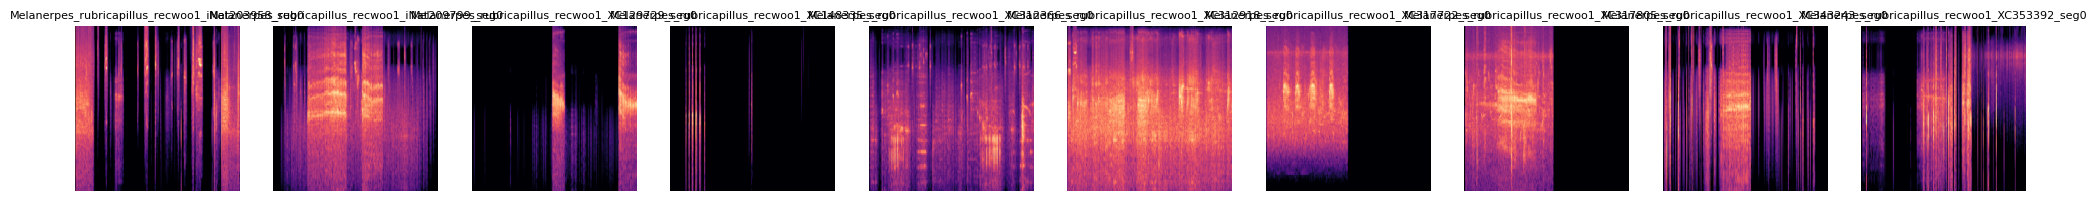

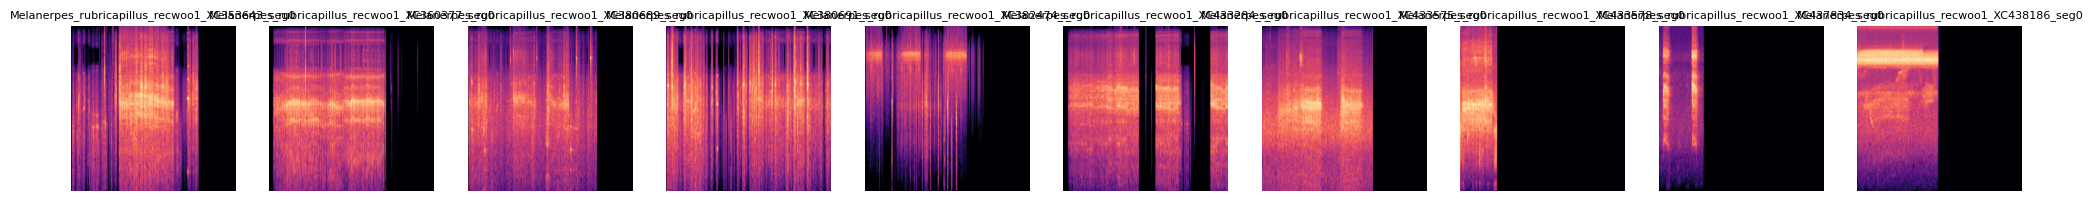

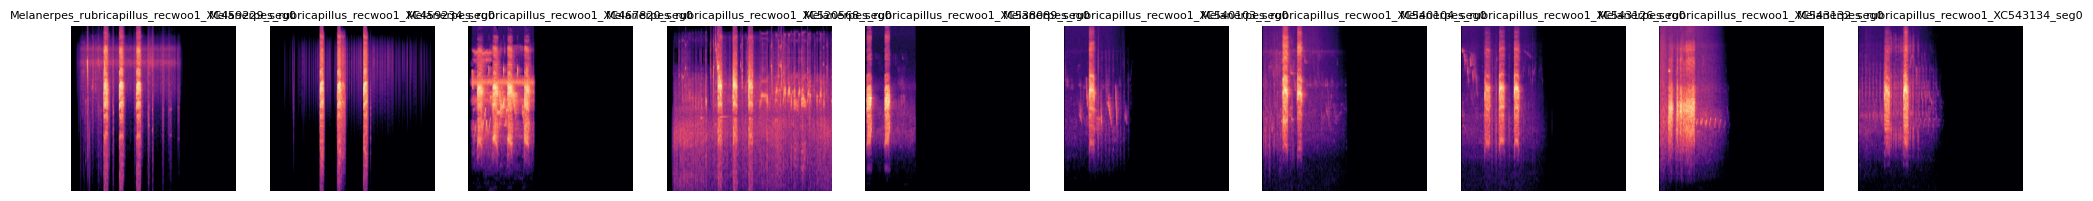

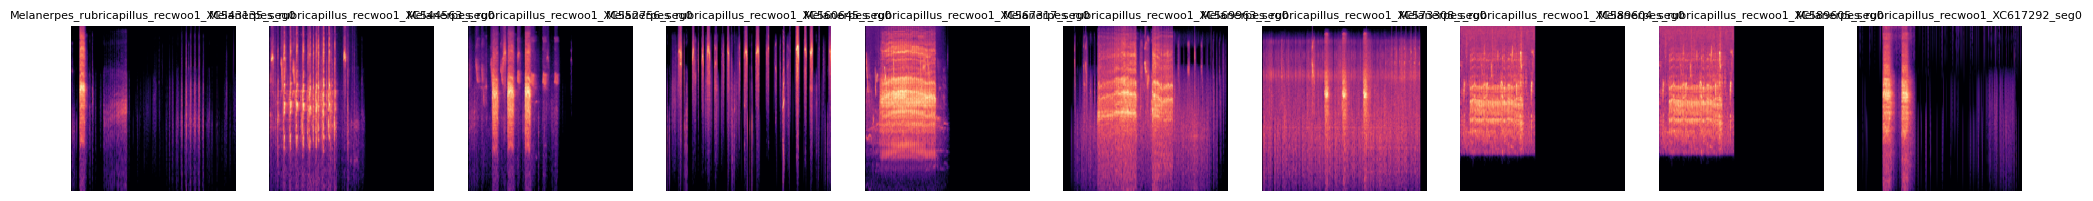

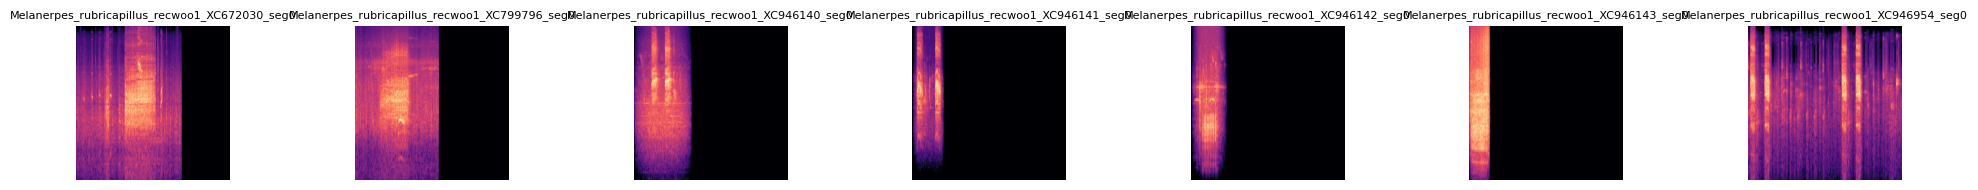

In [15]:
visualizar_espectrogramas_por_especie('Melanerpes rubricapillus')

La colección de **Mel-espectrogramas** generada para la especie *Melanerpes rubricapillus* sirve como una excelente validación visual de la **robustez y efectividad** del pipeline de preprocesamiento de audio implementado.  

El análisis de estas imágenes demuestra que las funciones de **limpieza de señal** y **extracción de características** operan correctamente, produciendo un conjunto de datos **estandarizado y de alta calidad**, listo para el entrenamiento de modelos de aprendizaje profundo.

#### **Puntos Técnicos Destacados**

1. **Efectividad de la Reducción de Ruido**  

   Se observa una notable claridad en la mayoría de los espectrogramas, donde las vocalizaciones (las formas brillantes) contrastan fuertemente con un fondo oscuro y limpio.  

   Esto demuestra el éxito del pipeline de preprocesamiento de dos etapas:  

   - El **filtro pasa-banda** ha eliminado eficazmente el ruido de baja frecuencia.  
   - La técnica de **reducción de ruido con wavelets** ha suprimido el ruido no estacionario sin degradar significativamente la señal de interés.

   El resultado son **características más definidas**, lo que reduce la ambigüedad para el modelo de clasificación.

2. **Preservación de Características Acústicas Clave**  

   A pesar del agresivo proceso de limpieza, las **firmas acústicas fundamentales** de la especie se han preservado con alta fidelidad. 

   Los **patrones rítmicos de pulsos verticales**, característicos del *“tamborileo”* de esta especie, son nítidos y bien definidos.

   Esto valida que la metodología de **denoising** es lo suficientemente sofisticada para distinguir entre el ruido y la señal útil, un concepto clave heredado de la literatura.

3. **Estandarización de la Entrada**  

   Todas las imágenes presentan una **dimensión y escala uniformes**. 

   Esto es el resultado directo de:  

   - La implementación de una **ventana deslizante** que segmenta el audio en fragmentos de 10 segundos.  
   - La aplicación consistente de los parámetros de `librosa.feature.melspectrogram`.  

   Esta estandarización es un requisito indispensable para el entrenamiento de **redes neuronales**, que requieren tensores de entrada de tamaño fijo.

4. **Captura de la Variabilidad Natural**  

   La colección de espectrogramas no es monótona; muestra una **variabilidad natural** en la intensidad, el espaciado y la duración de los pulsos entre diferentes segmentos.  

   Esto es positivo, ya que indica que el pipeline no está **sobre-procesando** el audio hasta eliminar las variaciones individuales.  
   
   Al capturar esta diversidad, se construye un conjunto de datos más **rico y representativo**, lo que es crucial para entrenar un modelo que pueda **generalizar a nuevas grabaciones no vistas**.


Los espectrogramas de *Melanerpes rubricapillus* no solo representan las **vocalizaciones de la especie**, sino que también actúan como una **prueba tangible** de que el pipeline de generación de datos es **robusto, eficiente** y está correctamente alineado con las **mejores prácticas de la bioacústica computacional**.